# Wide and Deep Neural Network
### by Pooya Valizadeh

what are Wide and Deep Neural networks???

Wide & Deep Neural Networks are a type of neural network architecture introduced by Google in 2016 that combines two different types of learning into one model:

Wide part → Learns memorization (remembers specific patterns/examples)

Deep part → Learns generalization (understands new, unseen patterns)

In [120]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

import warnings
warnings.filterwarnings("ignore")

In [121]:
from sklearn.datasets import fetch_california_housing as data
data()

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

## preprocessing

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


<Axes: >

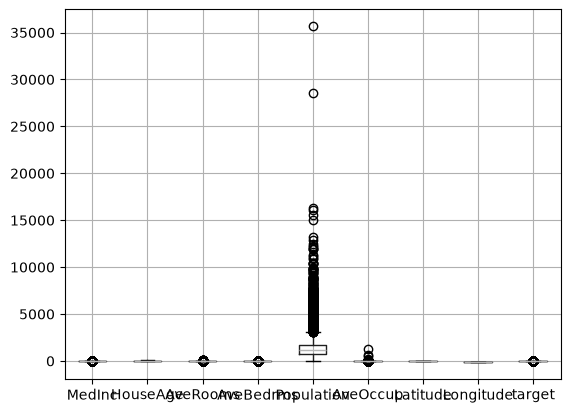

In [122]:
df = pd.DataFrame(data().data, columns=data().feature_names)
df['target'] = data().target

print(df.head())
df.boxplot()

In [123]:

df = df[(df < 12000).all(axis=1)]
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<Axes: >

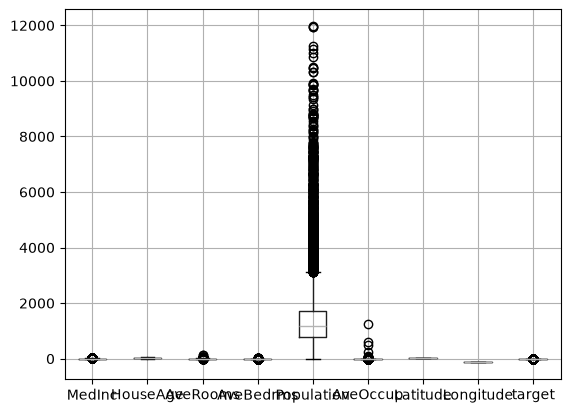

In [124]:
df.boxplot()

In [125]:
x = df.drop(columns="target").values
y = df["target"].values

In [126]:
xtest

array([[-0.43551895,  0.5800371 , -0.53872421, ..., -0.11186918,
        -1.3431042 ,  1.20649039],
       [-1.27796197,  0.50057891, -0.46524822, ..., -0.09830272,
        -0.72945816,  0.95680229],
       [-0.57864096, -0.69129397, -0.60041114, ..., -0.03593376,
        -0.66856199,  0.56728887],
       ...,
       [ 0.77261003, -1.00912674, -0.3496614 , ...,  0.12615078,
         0.79294614, -1.13558393],
       [-0.14980209,  1.85136817,  0.08628711, ..., -0.01340557,
         1.0084249 , -1.45518469],
       [-0.95144348,  0.02382976, -0.72042457, ...,  0.05093566,
        -0.74351112,  0.62721401]], shape=(4128, 8))

In [127]:
from sklearn.model_selection import train_test_split as tts 
xtrain , xtest , ytrain , ytest = tts(x,y,random_state=26,test_size=0.2)

In [138]:
print(xtrain.shape , ytrain.shape , xtest.shape , ytest.shape)

(16503, 8) (16503,) (4126, 8) (4126,)


In [128]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
xtrain = scale.fit_transform(xtrain)
xtest = scale.transform(xtest)

## bulding the model

In [129]:
from tensorflow.keras.layers import concatenate , Input , Dense

In [130]:
x.shape

(20629, 8)

In [131]:
input_ = Input(shape = (8,))
h1 = Dense(60,activation="relu")(input_)
h2 = Dense(10,activation="relu")(h1)
h3 = concatenate([input_,h2])
output = Dense(1)(h3)
model = keras.Model(input_,output)

In [132]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 60)        │        540 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 10)        │        610 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 18)        │          0 │ input_layer_7[0]… │
│ (Concatenate)       │                   │            │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 1)         │         19 │ concatenate_6[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,169 (4.57 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

In [133]:
model.compile(loss= keras.losses.MeanSquaredError(),optimizer= "Adam",metrics=[keras.metrics.MeanSquaredError()])

## training the model

In [134]:
history = model.fit(xtrain,ytrain,epochs=50,batch_size=100,validation_split=0.2)

Epoch 1/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.8292 - mean_squared_error: 1.8292 - val_loss: 0.7248 - val_mean_squared_error: 0.7248
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6362 - mean_squared_error: 0.6362 - val_loss: 0.5777 - val_mean_squared_error: 0.5777
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5246 - mean_squared_error: 0.5246 - val_loss: 0.4793 - val_mean_squared_error: 0.4793
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4639 - mean_squared_error: 0.4639 - val_loss: 0.4393 - val_mean_squared_error: 0.4393
Epoch 5/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4262 - mean_squared_error: 0.4262 - val_loss: 0.4091 - val_mean_squared_error: 0.4091
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4146 - mean_squared_error: 0.4146 - val_loss: 0.3909 - val_mean_squared_error: 0.3909
Epoch 7/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3916 - mean_squared_error: 0.3916 - val_loss: 0.37

<Axes: >

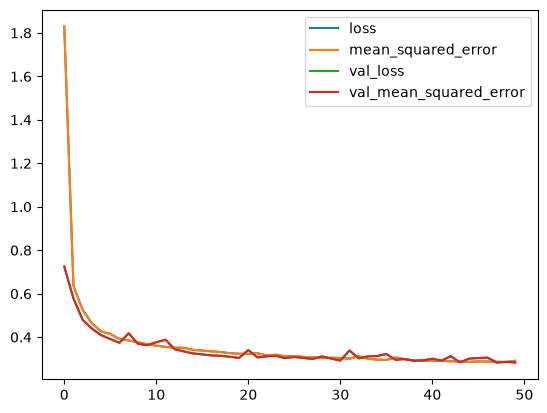

In [135]:
pd.DataFrame(history.history).plot()

## evaluate

In [139]:
model.evaluate(xtest,ytest)

  1/129 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.4699 - mean_squared_error: 0.4699

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2978 - mean_squared_error: 0.2978


[0.2977759838104248, 0.2977759838104248]